# D.R.O.N.A. — 05 Bias Detection Eval (C2)

Evaluate the rule-based cognitive-bias detector against the labelled `C2_QUERIES`
bank: per-bias and macro **precision / recall / F1**. The six biases follow
Tversky & Kahneman 1974 and the proposal's §Cognitive Biases.

This runs with **no external dependencies** (detector is keyword+regex, fully
transparent and falsifiable).

In [1]:
import sys; import os, pathlib
# Run from the repo root so relative data paths (settings.*) resolve correctly.
_root = pathlib.Path.cwd()
while not (_root / 'drona' / '__init__.py').exists() and _root != _root.parent:
    _root = _root.parent
os.chdir(_root)
sys.path.insert(0, str(_root))
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
from drona.utils.logging import setup_logging; setup_logging('WARNING')

from drona.evaluation.harness import EvaluationHarness
c2 = EvaluationHarness().eval_c2()
print(f'Queries: {c2.n_queries} ({c2.n_with_bias} biased, {c2.n_clean} clean)')
print('Macro:', {k: round(v, 3) for k, v in c2.macro_avg.items()})

Queries: 16 (13 biased, 3 clean)
Macro: {'precision': 1.0, 'recall': 0.806, 'f1': 0.861}


In [2]:
rows = []
for bias, m in c2.per_bias_metrics.items():
    if m.get('tp', 0) + m.get('fn', 0) > 0:
        rows.append({'bias': bias, 'precision': m['precision'], 'recall': m['recall'],
                     'f1': m['f1'], 'tp': m['tp'], 'fp': m['fp'], 'fn': m['fn']})
df = pd.DataFrame(rows).set_index('bias').round(3)
display(df)

,precision,recall,f1,tp,fp,fn
bias,,,,,,
availability_heuristic,1.0,1.000,1.000,3,0,0
anchoring,1.0,0.500,0.667,2,0,2
confirmation,1.0,0.333,0.500,1,0,2
dunning_kruger,1.0,1.000,1.000,2,0,0
loss_aversion,1.0,1.000,1.000,2,0,0
consistency,1.0,1.000,1.000,2,0,0


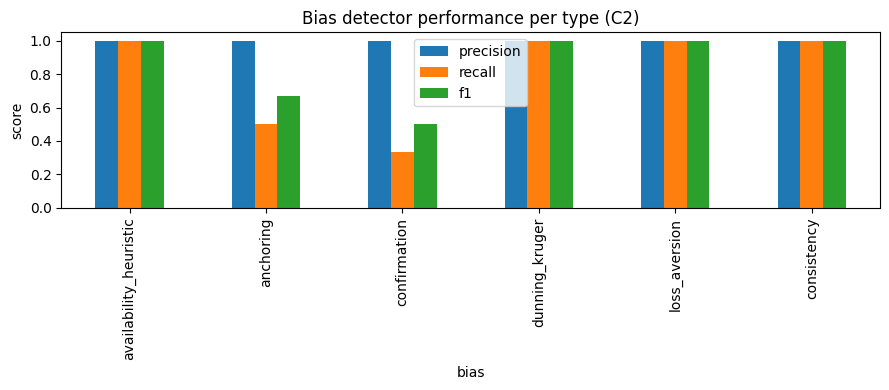

In [3]:
import matplotlib.pyplot as plt
if not df.empty:
    ax = df[['precision', 'recall', 'f1']].plot(kind='bar', figsize=(9, 4))
    ax.set_title('Bias detector performance per type (C2)')
    ax.set_ylim(0, 1.05); ax.set_ylabel('score'); plt.tight_layout(); plt.show()

In [4]:
# Inspect individual decisions to keep the detector falsifiable.
from drona.advising.bias_detector import BiasDetector
from drona.evaluation.queries import C2_QUERIES
det = BiasDetector()
for q in C2_QUERIES[:4]:
    flags = det.detect(q.query_text)
    print('Q:', q.query_text[:70])
    print('   expected:', q.expected_biases, '| detected:', [f.bias_type for f in flags])

Q: My friend got a job at Leapfrog earning Rs 80,000. How do I get there?
   expected: ['availability_heuristic', 'anchoring'] | detected: ['availability_heuristic']
Q: I heard AI pays really well these days. Should I focus only on AI?
   expected: ['availability_heuristic', 'anchoring'] | detected: ['availability_heuristic']
Q: Everyone says cloud computing is the future. What do you think?
   expected: ['availability_heuristic', 'confirmation'] | detected: ['availability_heuristic']
Q: I only want to work at Google or Microsoft, nowhere else. How do I qua
   expected: ['anchoring'] | detected: ['anchoring']


**Output:** per-bias P/R/F1 + macro average. Clean queries (no bias) test
precision — false positives would erode student trust. The detector is
intentionally rule-based so every decision is explainable at viva.